## Pulse-coupled fish: looming input and social escapes

Each fish combines leaky evidence accumulation, neighbour escape pulses,
and independent Gaussian noise:

$$\Delta x_i = \frac{\Delta t}{\tau}
\left[-x_i(t) + L_i(t) + w\sum_j A_{ij}s_j(t-\Delta t)\right]
+ \sigma\sqrt{\Delta t}\,\xi_{i,t}.$$

Here, $x_i$ is `fish.evidence`, $L_i$ is the fish's external input, $\tau$ is
`tau_evidence`, and $w$ is `social_strength`. $A_{ij}$ is the connection weight
from fish $j$ to fish $i$, and $s_j$ is an escape spike. Each $\xi_{i,t}$ is an
independent standard normal draw, scaled by `noise_strength` and `np.sqrt(dt)`.
Time is in seconds.

Sheltered and unsheltered fish use the same evidence update. Direct and social
inputs are added together in the drift, which pulls evidence toward their sum
with timescale `tau_evidence`. When both inputs are absent, evidence relaxes
toward zero. Both input contributions are scaled by `dt / tau_evidence`.
Gaussian noise is added separately and can move evidence up or down in either
state, including below zero.

State only determines which behavioral threshold applies. Reaching `threshold`
while unsheltered triggers escape and emits one spike. A sheltered fish recovers
strictly below `recovery_threshold`. Remaining sheltered emits no further spikes.

Only the first `n_exposed` fish receive the external stimulus directly. Every fish can receive
neighbour escape pulses. `random_seed` makes runs reproducible;
`noise_strength = 0` removes noise and `social_strength = 0` removes social input.
Reusable code lives in [agent.py](agent.py), [stimulus.py](stimulus.py),
and [network.py](network.py).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from agent import Agent
from stimulus import loom, square_wave
from network import all_to_all

In [2]:
## Group size, timing, and state thresholds
n_fish = 20
total_time = 1.0
dt = 0.001
tau_evidence = 0.1
threshold = 0.5
recovery_threshold = 0.1

In [3]:
## Evidence noise
noise_strength = 0.2
random_seed = 2026

## Social input amplitude per neighbour escape
social_strength = 0.1

## External stimulus
n_exposed = 5
stimulus_start = 0.2
stimulus_strength = 1.0

## Object size and approach
object_radius = 0.02
start_distance = 0.20
end_distance = 0.05
approach_speed = 0.50

The simulation uses exactly `n_steps` updates, indexed from `0` through
`n_steps - 1`. Times mark update starts; histories store results after each update.

In [4]:
n_steps = round(total_time / dt)
time = np.arange(n_steps) * dt

## Angular-size loom

An approaching disk has angular size $\theta = 2\arctan(R/d)$, where $R$ is
`object_radius` and $d$ is its distance. Lengths are in metres and
`approach_speed` is in metres per second. The geometry values are illustrative.

The stimulus appears at `start_distance` and disappears at `end_distance`.
Duration is the distance travelled divided by `approach_speed`. Input is
proportional to angular size, scaled toward `stimulus_strength` at the endpoint.
The finite starting distance gives a nonzero onset; the exclusive end means
its last sampled value is slightly below the endpoint strength.

With fixed geometry, increasing speed shortens the approach while keeping the
endpoint strength fixed. This version does not assign lower amplitudes to slow
approaches or impose a preference for intermediate speeds.

[stimulus.py](stimulus.py) provides `loom` and `square_wave`. Both return one
input value per timestep. The cell below chooses the loom. A square-pulse
alternative, with its duration specified in seconds, is:

```python
external_input = square_wave(
    time, stimulus_strength, duration=0.3, start=stimulus_start,
)
```

A custom stimulus can replace `external_input` with another array of the same
length as `time`; the fish update loop uses that array directly.

In [5]:
external_input = loom(
    time, stimulus_strength, object_radius, start_distance,
    end_distance, approach_speed, start=stimulus_start,
)

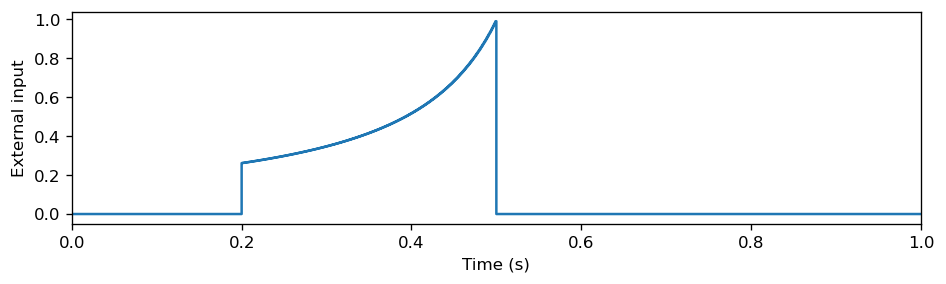

In [6]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.step(time, external_input, where="post")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="External input")
fig.tight_layout()
plt.show()

## Social interactions

`all_to_all` in [network.py](network.py) returns an editable adjacency matrix.
`adjacency[i, j]` is the weight of the connection from fish `j` to fish `i`.
The default connects every fish to every other fish with the diagonal set to
zero, so a fish does not respond to its own escape.

Setting `adjacency[i, j] = 0` removes that connection; a weight of `0.5` halves
its contribution. Setting both `[i, j]` and `[j, i]` changes the connection in
both directions. A different network can replace this matrix as long as its
shape remains `(n_fish, n_fish)`. Network edits belong after the construction
cell and before the simulation loop.

Each neighbour escape supplies a one-timestep social input of amplitude
`social_strength` times its connection weight. Inputs from multiple neighbours
add together. Direct and social inputs enter the same drift term, so one social
pulse contributes `social_strength * weight * dt / tau_evidence` to evidence.
The accumulated evidence subsequently decays through the same leak.

`social_strength` describes an input level. The cue currently lasts one timestep,
so its total contribution depends on `dt`. The archived model uses the same drift
form with separately specified cue durations.

`adjacency @ previous_spikes` sums neighbour escape spikes for each fish.
Pulses arrive one timestep after escape. All social inputs are computed before
any fish updates, so newly triggered escapes affect neighbours on the next
step, regardless of loop order.

In [7]:
adjacency = all_to_all(n_fish)

In [8]:
evidence_history = np.zeros((n_fish, n_steps))
escape_spikes = np.zeros((n_fish, n_steps))
state_history = np.zeros((n_fish, n_steps))

History rows represent fish and columns represent timesteps. Escape spikes
mark transitions into shelter; recovery occurs below `recovery_threshold`.

In [9]:
agents = [Agent() for _ in range(n_fish)]
rng = np.random.default_rng(random_seed)
previous_spikes = np.zeros(n_fish)

for step in range(n_steps):
    social_input = social_strength * (adjacency @ previous_spikes)
    for fish_id, fish in enumerate(agents):
        direct_input = external_input[step] if fish_id < n_exposed else 0.0
        total_input = direct_input + social_input[fish_id]
        drift = (total_input - fish.evidence) / tau_evidence
        change = drift * dt
        change += noise_strength * np.sqrt(dt) * rng.normal()
        fish.evidence += change
        if fish.state == 0:
            if fish.evidence >= threshold:
                fish.state = 1
                escape_spikes[fish_id, step] = 1
        elif fish.evidence < recovery_threshold:
            fish.state = 0
        evidence_history[fish_id, step] = fish.evidence
        state_history[fish_id, step] = fish.state
    previous_spikes = escape_spikes[:, step].copy()

## Evidence over time

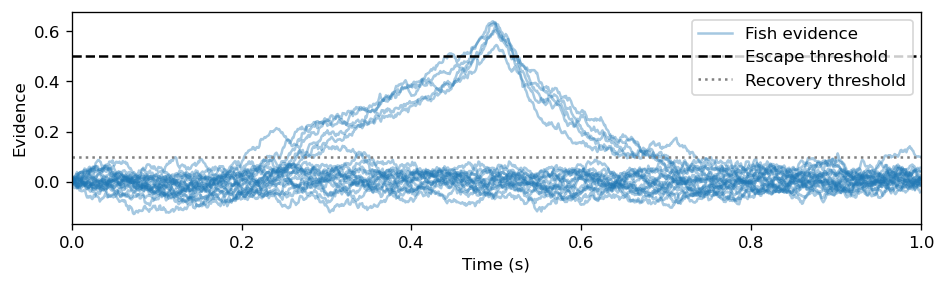

In [10]:
fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(time, evidence_history.T, color="tab:blue", alpha=0.4)
lines[0].set_label("Fish evidence")
ax.axhline(threshold, color="black", linestyle="--", label="Escape threshold")
ax.axhline(recovery_threshold, color="grey", linestyle=":",
           label="Recovery threshold")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Evidence")
ax.legend()
fig.tight_layout()
plt.show()

## Escape spikes

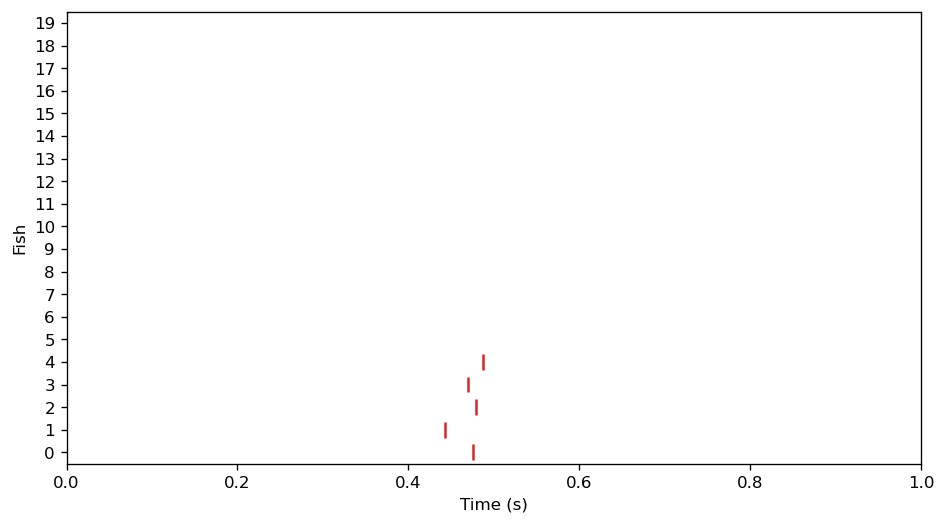

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fish_id in range(n_fish):
    escape_times = time[escape_spikes[fish_id] == 1]
    ax.vlines(escape_times, fish_id - 0.35, fish_id + 0.35, color="tab:red")
ax.set(xlim=(0, total_time), ylim=(-0.5, n_fish - 0.5))
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
fig.tight_layout()
plt.show()

## Shelter state

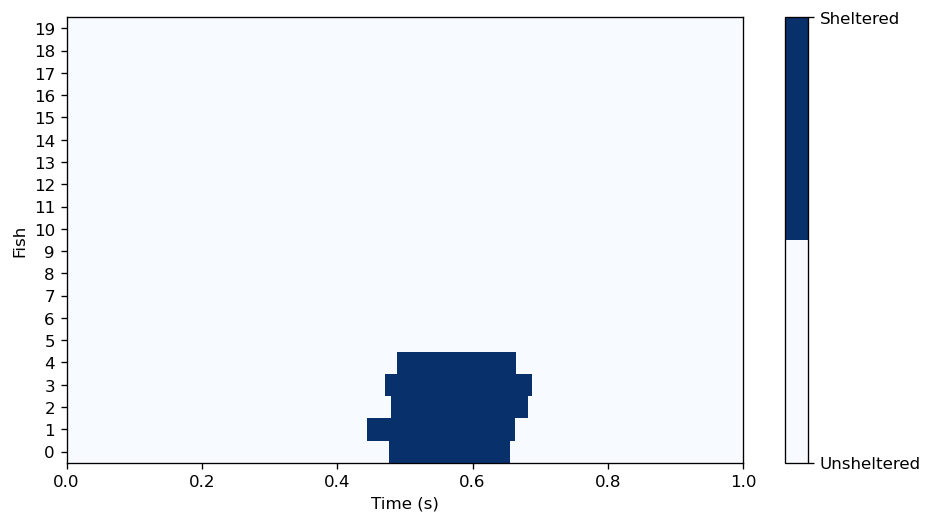

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(state_history, origin="lower", aspect="auto",
                  extent=(0, total_time, -0.5, n_fish - 0.5),
                  cmap=plt.get_cmap("Blues", 2), vmin=0, vmax=1,
                  interpolation="nearest")
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Unsheltered", "Sheltered"])
fig.tight_layout()
plt.show()